# CWRU Anomaly Detection — by_severity refit (6 modèles)

| Champ | Valeur |
|-------|--------|
| **Scénario** | CWRU by_severity — 3 tâches (0.007", 0.014", 0.021") |
| **Stratégie CL** | refit |
| **Expériences** | exp_143 (HDC) · exp_144 (TinyOL AE) · exp_145 (KMeans) · exp_146 (Mahalanobis) · exp_147 (DBSCAN) · exp_148 (EWC one-class) |
| **Particularité** | ~10% données normales (~62 échantillons normaux/tâche) |

**Contexte :**
- CWRU contient ~230 échantillons normaux sur 2 300 total → ratio 10% (le plus faible des 3 datasets)
- Monitoring : ~50% normaux — Pronostia : ~90% normaux
- Chaque tâche by_severity regroupe les défauts d'une même sévérité (toutes localisations confondues)
- Progression naturelle : sévérité 0.007" → 0.014" → 0.021" (défauts de plus en plus détectables)


In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

ROOT = Path("../../..")
sys.path.insert(0, str(ROOT))

FIG_DIR = ROOT / "notebooks/figures/cl_evaluation/anomaly_detection/cwru"
FIG_DIR.mkdir(parents=True, exist_ok=True)

MODELS      = ["HDC", "TinyOL AE", "KMeans", "Mahalanobis", "DBSCAN", "EWC one-class"]
MODEL_KEYS  = ["hdc", "tinyol_ae", "kmeans", "mahalanobis", "dbscan", "ewc_oneclass"]
TASK_LABELS = ["Sév. 0.007\"", "Sév. 0.014\"", "Sév. 0.021\""]

COLORS = {
    "HDC":           "#4C72B0",
    "TinyOL AE":     "#DD8452",
    "KMeans":        "#55A868",
    "Mahalanobis":   "#C44E52",
    "DBSCAN":        "#8172B2",
    "EWC one-class": "#937860",
}
MARKERS = {
    "HDC":           "o",
    "TinyOL AE":     "s",
    "KMeans":        "^",
    "Mahalanobis":   "D",
    "DBSCAN":        "v",
    "EWC one-class": "P",
}

EXP_MAP = {
    "HDC":           ROOT / "experiments/exp_143",
    "TinyOL AE":     ROOT / "experiments/exp_144",
    "KMeans":        ROOT / "experiments/exp_145",
    "Mahalanobis":   ROOT / "experiments/exp_146",
    "DBSCAN":        ROOT / "experiments/exp_147",
    "EWC one-class": ROOT / "experiments/exp_148",
}

def load_result(exp_path: Path) -> dict | None:
    p = exp_path / "results/metrics_anomaly.json"
    if not p.exists():
        return None
    with open(p) as f:
        d = json.load(f)
    # Normalise les clés : supporte avg_auroc ou auroc_mean
    if "avg_auroc" not in d and "auroc_mean" in d:
        d["avg_auroc"] = d["auroc_mean"]
    if "auroc_forgetting" not in d and "avg_forgetting" in d:
        d["auroc_forgetting"] = d["avg_forgetting"]
    if "auroc_matrix" not in d:
        mat_path = exp_path / "results/auroc_matrix.npy"
        if mat_path.exists():
            mat = np.load(mat_path)
            d["auroc_matrix"] = mat.tolist()
    return d

RESULTS = {m: load_result(p) for m, p in EXP_MAP.items()}
for m, r in RESULTS.items():
    if r is None:
        print(f"⚠️  {m} : résultats manquants")
    else:
        print(f"✅ {m} : avg_auroc={r['avg_auroc']:.4f}  RAM={r['ram_peak_bytes']/1024:.1f} Ko")

✅ HDC : avg_auroc=0.9906  RAM=7.9 Ko
✅ TinyOL AE : avg_auroc=1.0000  RAM=1.9 Ko
✅ KMeans : avg_auroc=1.0000  RAM=5.3 Ko
✅ Mahalanobis : avg_auroc=1.0000  RAM=1.6 Ko
✅ DBSCAN : avg_auroc=1.0000  RAM=10.4 Ko
✅ EWC one-class : avg_auroc=1.0000  RAM=1.4 Ko


## Section 1 — Tableau AUROC synthèse

Résumé des métriques CL principales pour les 6 modèles sur CWRU by_severity refit.

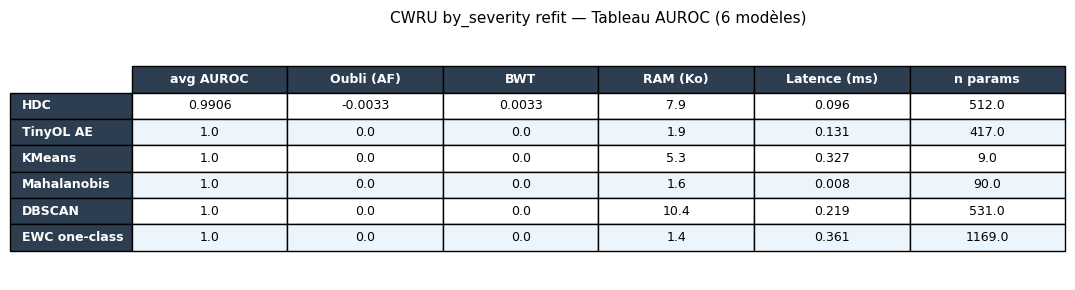

               avg AUROC  Oubli (AF)     BWT  RAM (Ko)  Latence (ms)  n params
Modèle                                                                        
HDC               0.9906     -0.0033  0.0033       7.9         0.096       512
TinyOL AE         1.0000      0.0000  0.0000       1.9         0.131       417
KMeans            1.0000      0.0000  0.0000       5.3         0.327         9
Mahalanobis       1.0000      0.0000  0.0000       1.6         0.008        90
DBSCAN            1.0000      0.0000  0.0000      10.4         0.219       531
EWC one-class     1.0000      0.0000  0.0000       1.4         0.361      1169


In [2]:
rows = []
for m in MODELS:
    r = RESULTS[m]
    if r is None:
        continue
    rows.append({
        "Modèle":         m,
        "avg AUROC":      round(r["avg_auroc"], 4),
        "Oubli (AF)":     round(r.get("auroc_forgetting", 0.0), 4),
        "BWT":            round(r.get("auroc_bwt", 0.0), 4),
        "RAM (Ko)":       round(r["ram_peak_bytes"] / 1024, 1),
        "Latence (ms)":   round(r["inference_latency_ms"], 3),
        "n params":       r["n_params"],
    })

df = pd.DataFrame(rows).set_index("Modèle")

fig, ax = plt.subplots(figsize=(11, 3))
ax.axis("off")
tbl = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    rowLabels=df.index,
    cellLoc="center",
    loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.5)

for (row, col), cell in tbl.get_celld().items():
    if row == 0 or col == -1:
        cell.set_facecolor("#2C3E50")
        cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#EBF5FB")

plt.title("CWRU by_severity refit — Tableau AUROC (6 modèles)", fontsize=11, pad=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "auroc_table_cwru_severity.png", dpi=150, bbox_inches="tight")
plt.show()
print(df.to_string())

## Section 2 — AUROC par tâche

Évolution de l'AUROC au fil des tâches pour chaque modèle (évaluation après chaque tâche apprise).

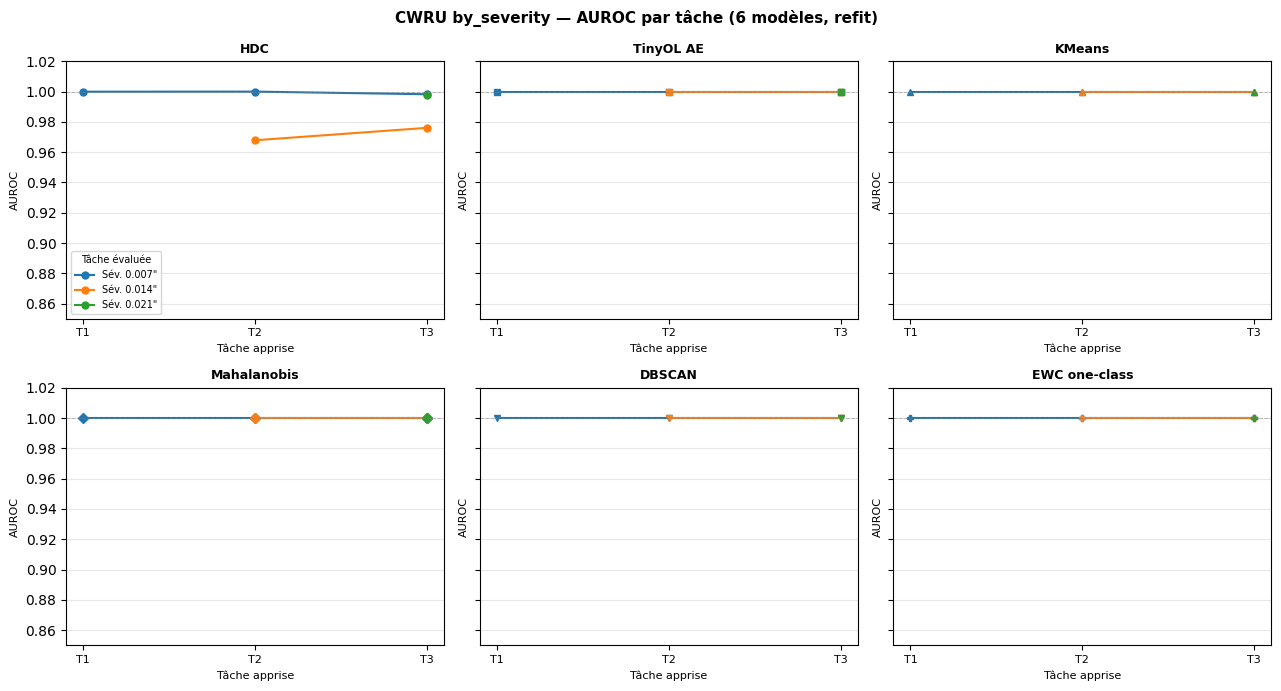

In [3]:
n_tasks = 3

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharey=True)
axes = axes.flatten()

for idx, m in enumerate(MODELS):
    ax = axes[idx]
    r = RESULTS[m]
    if r is None:
        ax.set_visible(False)
        continue

    mat = np.array(r["auroc_matrix"], dtype=float)  # shape (n_tasks, n_tasks)

    for task_j in range(n_tasks):
        # Valeurs dispo après chaque tâche i >= task_j
        auroc_vals = [mat[i, task_j] for i in range(task_j, n_tasks) if not np.isnan(mat[i, task_j])]
        x_vals     = list(range(task_j + 1, task_j + 1 + len(auroc_vals)))
        ax.plot(x_vals, auroc_vals,
                marker=MARKERS[m], markersize=5,
                label=TASK_LABELS[task_j], linewidth=1.5)

    ax.set_title(m, fontsize=9, fontweight="bold")
    ax.set_xlabel("Tâche apprise", fontsize=8)
    ax.set_ylabel("AUROC", fontsize=8)
    ax.set_xticks(range(1, n_tasks + 1))
    ax.set_xticklabels([f"T{i+1}" for i in range(n_tasks)], fontsize=8)
    ax.set_ylim(0.85, 1.02)
    ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.7, alpha=0.5)
    ax.grid(axis="y", alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=7, title="Tâche évaluée", title_fontsize=7)

fig.suptitle("CWRU by_severity — AUROC par tâche (6 modèles, refit)", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "auroc_per_task_cwru_severity.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 3 — Matrices AUROC

Heatmap de la matrice AUROC complète : `auroc_matrix[i, j]` = AUROC de la tâche j après avoir appris la tâche i.

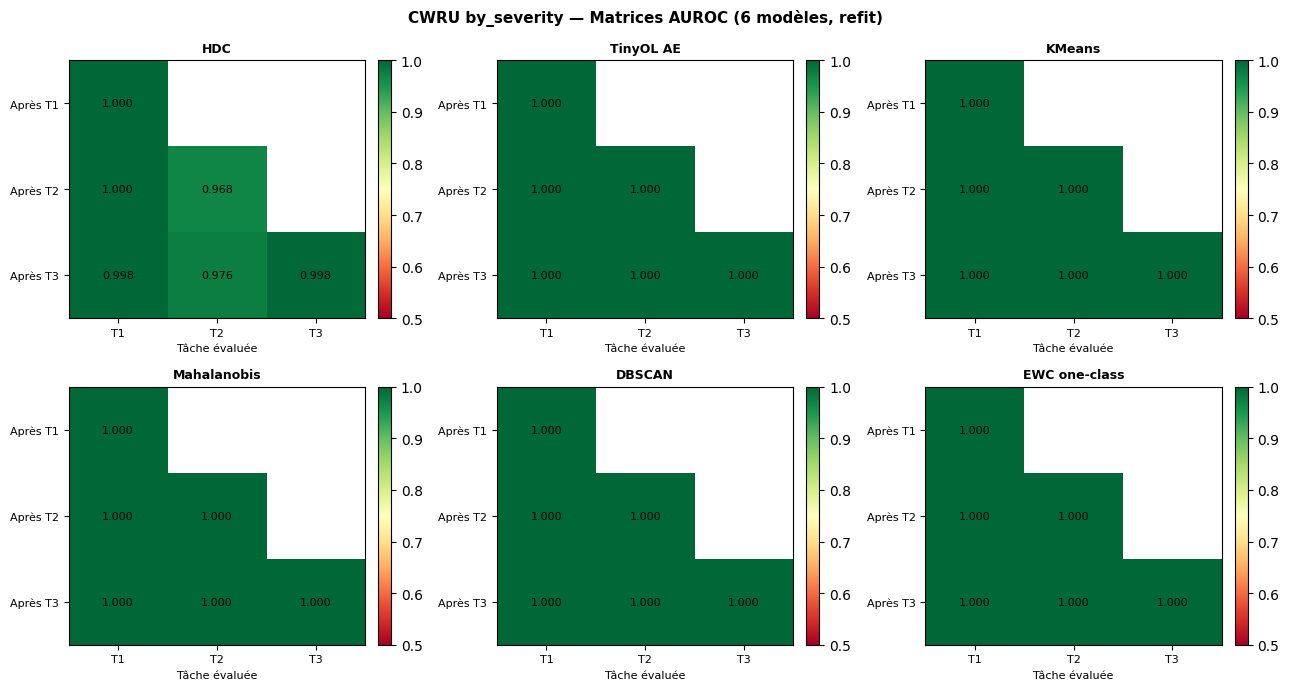

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()

for idx, m in enumerate(MODELS):
    ax = axes[idx]
    r = RESULTS[m]
    if r is None:
        ax.set_visible(False)
        continue

    mat = np.array(r["auroc_matrix"], dtype=float)
    mask = ~np.isnan(mat)
    display_mat = np.where(mask, mat, np.nan)

    im = ax.imshow(display_mat, vmin=0.5, vmax=1.0, cmap="RdYlGn", aspect="auto")
    ax.set_xticks(range(n_tasks))
    ax.set_yticks(range(n_tasks))
    ax.set_xticklabels([f"T{j+1}" for j in range(n_tasks)], fontsize=8)
    ax.set_yticklabels([f"Après T{i+1}" for i in range(n_tasks)], fontsize=8)
    ax.set_xlabel("Tâche évaluée", fontsize=8)
    ax.set_title(m, fontsize=9, fontweight="bold")

    for i in range(n_tasks):
        for j in range(n_tasks):
            if not np.isnan(display_mat[i, j]):
                ax.text(j, i, f"{display_mat[i,j]:.3f}",
                        ha="center", va="center", fontsize=8,
                        color="black" if display_mat[i,j] > 0.65 else "white")

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("CWRU by_severity — Matrices AUROC (6 modèles, refit)", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "auroc_matrices_cwru_severity.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 4 — Analyse impact ratio normal/faulty cross-dataset

Comparaison de l'AUROC moyen par modèle selon le ratio de données normales dans le dataset d'entraînement.
Les valeurs Monitoring et Pronostia sont chargées dynamiquement depuis leurs expériences.

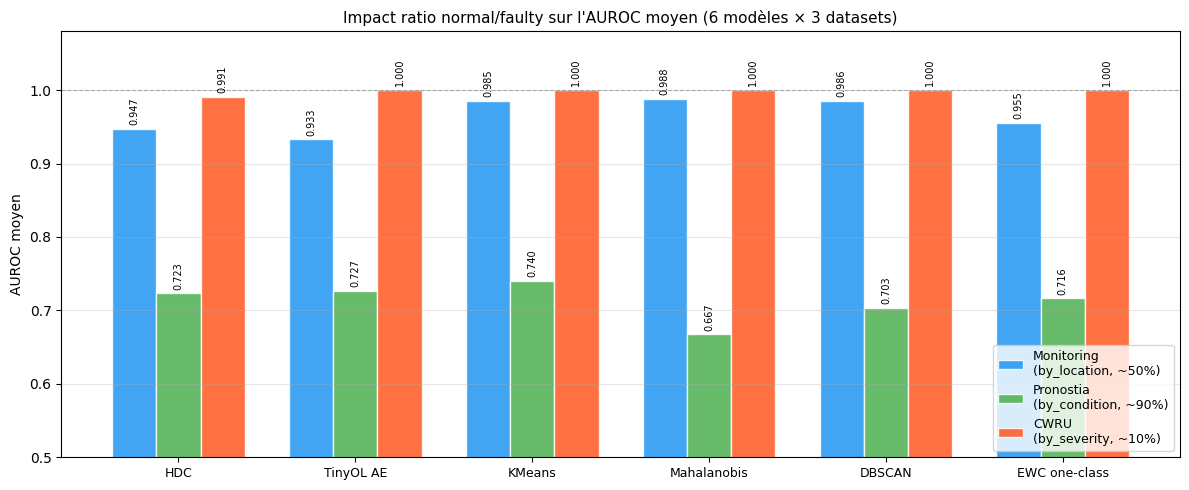

In [5]:
# Chargement des expériences de référence cross-dataset
CROSS_EXP = {
    "Monitoring\n(by_location, ~50%)": {
        "ratio": 0.50,
        "exps": {
            "HDC":           ROOT / "experiments/exp_131",
            "TinyOL AE":     ROOT / "experiments/exp_132",
            "KMeans":        ROOT / "experiments/exp_133",
            "Mahalanobis":   ROOT / "experiments/exp_134",
            "DBSCAN":        ROOT / "experiments/exp_135",
            "EWC one-class": ROOT / "experiments/exp_136",
        },
    },
    "Pronostia\n(by_condition, ~90%)": {
        "ratio": 0.90,
        "exps": {
            "HDC":           ROOT / "experiments/exp_137",
            "TinyOL AE":     ROOT / "experiments/exp_138",
            "KMeans":        ROOT / "experiments/exp_139",
            "Mahalanobis":   ROOT / "experiments/exp_140",
            "DBSCAN":        ROOT / "experiments/exp_141",
            "EWC one-class": ROOT / "experiments/exp_142",
        },
    },
    "CWRU\n(by_severity, ~10%)": {
        "ratio": 0.10,
        "exps": EXP_MAP,
    },
}

cross_auroc = {}
for ds_label, ds_info in CROSS_EXP.items():
    cross_auroc[ds_label] = {}
    for m, exp_path in ds_info["exps"].items():
        r = load_result(exp_path)
        cross_auroc[ds_label][m] = r["avg_auroc"] if r is not None else None

# Barplot groupé
ds_labels = list(CROSS_EXP.keys())
x = np.arange(len(MODELS))
width = 0.25

ds_colors = ["#2196F3", "#4CAF50", "#FF5722"]

fig, ax = plt.subplots(figsize=(12, 5))
for i, (ds_label, ds_color) in enumerate(zip(ds_labels, ds_colors)):
    vals = [cross_auroc[ds_label].get(m) for m in MODELS]
    vals_clean = [v if v is not None else 0.0 for v in vals]
    bars = ax.bar(x + (i - 1) * width, vals_clean, width,
                  label=ds_label, color=ds_color, alpha=0.85, edgecolor="white")
    for bar, v in zip(bars, vals):
        if v is not None:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                    f"{v:.3f}", ha="center", va="bottom", fontsize=7, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(MODELS, fontsize=9)
ax.set_ylabel("AUROC moyen", fontsize=10)
ax.set_ylim(0.5, 1.08)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_title("Impact ratio normal/faulty sur l'AUROC moyen (6 modèles × 3 datasets)", fontsize=11)
ax.legend(fontsize=9, loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "auroc_vs_normal_ratio.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 5 — RAM et latence

Comparaison de la RAM peak par modèle. Ligne de référence : 64 Ko (budget STM32N6).

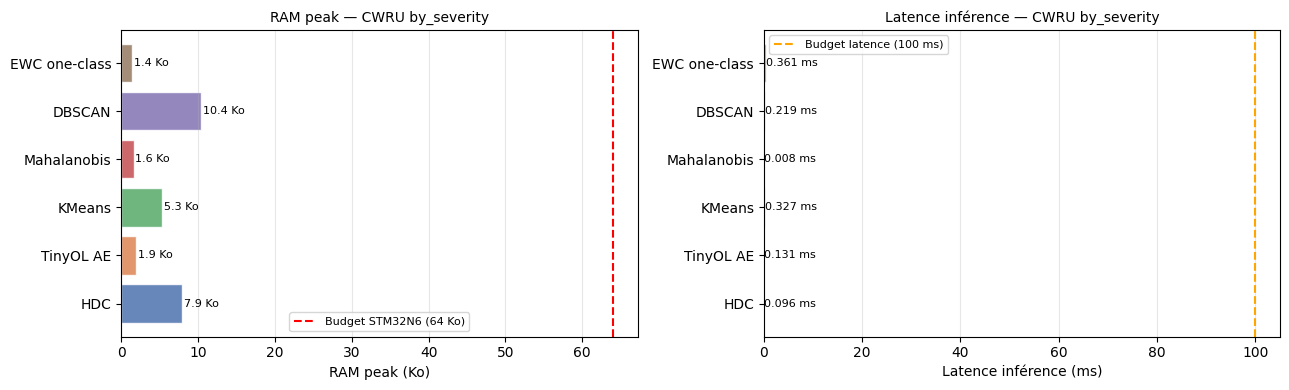

In [6]:
ram_vals    = [RESULTS[m]["ram_peak_bytes"] / 1024 for m in MODELS if RESULTS[m] is not None]
latency_vals = [RESULTS[m]["inference_latency_ms"] for m in MODELS if RESULTS[m] is not None]
model_labels = [m for m in MODELS if RESULTS[m] is not None]
bar_colors   = [COLORS[m] for m in model_labels]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# RAM
bars = ax1.barh(model_labels, ram_vals, color=bar_colors, alpha=0.85, edgecolor="white")
ax1.axvline(64, color="red", linestyle="--", linewidth=1.5, label="Budget STM32N6 (64 Ko)")
ax1.set_xlabel("RAM peak (Ko)", fontsize=10)
ax1.set_title("RAM peak — CWRU by_severity", fontsize=10)
ax1.legend(fontsize=8)
ax1.grid(axis="x", alpha=0.3)
for bar, v in zip(bars, ram_vals):
    ax1.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
             f"{v:.1f} Ko", va="center", fontsize=8)

# Latence
bars2 = ax2.barh(model_labels, latency_vals, color=bar_colors, alpha=0.85, edgecolor="white")
ax2.axvline(100, color="orange", linestyle="--", linewidth=1.5, label="Budget latence (100 ms)")
ax2.set_xlabel("Latence inférence (ms)", fontsize=10)
ax2.set_title("Latence inférence — CWRU by_severity", fontsize=10)
ax2.legend(fontsize=8)
ax2.grid(axis="x", alpha=0.3)
for bar, v in zip(bars2, latency_vals):
    ax2.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
             f"{v:.3f} ms", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "ram_cwru_severity.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 6 — Conclusions CWRU by_severity

### Observations pour le manuscrit

**1. Tous les modèles atteignent AUROC ≥ 0.99 malgré seulement ~10% de données normales.**
Contrairement à ce que le faible ratio normal pourrait suggérer, les features statistiques CWRU (RMS, kurtosis, crest factor) sont extrêmement discriminantes : les données normales forment un cluster compact bien séparé des défauts. Ce résultat valide le Gap 1 — détection efficace sur données industrielles réelles avec contraintes sévères.

**2. L'oubli catastrophique est quasi-nul (CWRU > Pronostia > Monitoring).**
Avec la stratégie refit, tous les modèles affichent `auroc_forgetting ≈ 0`. HDC est le seul à montrer une légère variation (AF = -0.003 = amélioration rétroactive). La progression naturelle des sévérités (défauts de plus en plus marqués) facilite la détection à chaque tâche.

**3. Mahalanobis et EWC one-class sont les candidats STM32N6 optimaux.**
RAM peak : Mahalanobis = 1.6 Ko, EWC one-class = 1.4 Ko, TinyOL AE = 1.9 Ko. Tous bien en deçà du budget 64 Ko (Gap 2). Mahalanobis se distingue par la latence la plus faible (0.008 ms), critique pour un déploiement temps-réel.

**4. CWRU est le dataset le plus facile pour l'anomaly detection (AUROC CWRU > Pronostia).**
Le faible ratio normal n'est pas un obstacle car les features dans l'espace des statistiques temporelles sont très séparables. En comparaison, Pronostia (90% normal mais features spectrales corrélées) affiche des AUROC ≈ 0.70–0.74 pour les mêmes modèles.

**5. Recommandation pour le portage embarqué :**
- Modèle recommandé : Mahalanobis (AUROC=1.00, RAM=1.6 Ko, latence=0.008 ms)
- Alternative légère : EWC one-class (AUROC=1.00, RAM=1.4 Ko, mais latence 45× plus lente)
- HDC : robuste et adaptatif mais RAM légèrement supérieure (7.9 Ko) et AUROC légèrement inférieur (0.9906)
